In [1]:
import numpy as np
import pandas as pd

features = list()

with open('UCI_HAR_Dataset/features.txt') as f:
    features = [line.split()[1] for line in f.readlines()]

print('No of Features: {}'.format(len(features)))

No of Features: 561


Getting the train data

In [3]:
import pandas as pd

BASE_PATH = 'UCI_HAR_Dataset'

features = pd.read_csv(
    f'{BASE_PATH}/features.txt',
    sep=r'\s+', header=None, usecols=[1]
)
features = features[1].tolist()

X_train = pd.read_csv(
    f'{BASE_PATH}/train/X_train.txt',
    sep=r'\s+', header=None
)
X_train.columns = features

subject_train = pd.read_csv(
    f'{BASE_PATH}/train/subject_train.txt',
    header=None, names=['subject']
)

y_train = pd.read_csv(
    f'{BASE_PATH}/train/y_train.txt',
    header=None, names=['Activity']
)

activity_labels = pd.read_csv(
    f'{BASE_PATH}/activity_labels.txt',
    sep=r'\s+', header=None, names=['Activity', 'ActivityName']
)

y_train = y_train.merge(activity_labels, on='Activity', how='left')

train = pd.concat([X_train, subject_train, y_train], axis=1)

print("Train shape:", train.shape)
train.sample(2)

Train shape: (7352, 564)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
2021,0.157170,-0.026741,-0.050692,0.189703,0.102090,-0.231475,0.143389,-0.026124,-0.227080,0.581651,...,0.449855,0.889155,0.756807,-0.805151,-0.753546,0.229223,-0.094514,11,3,WALKING_DOWNSTAIRS
6681,0.277258,-0.017145,-0.108763,-0.994575,-0.988155,-0.983139,-0.994868,-0.987543,-0.982701,-0.940022,...,0.441056,-0.447106,0.208235,-0.247208,-0.661197,-0.039278,-0.180279,29,4,SITTING


In [4]:
print(train.shape)

print(train.columns[-5:])

print(train['ActivityName'].value_counts())


(7352, 564)
Index(['angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity',
       'ActivityName'],
      dtype='str')
ActivityName
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


Getting the train data

In [5]:
import pandas as pd

base_path = 'UCI_HAR_Dataset'

X_test = pd.read_csv(
    f'{base_path}/test/X_test.txt',
    sep=r'\s+',
    header=None
)
X_test.columns = features

subject_test = pd.read_csv(
    f'{base_path}/test/subject_test.txt',
    header=None,
    names=['subject']
)

y_test = pd.read_csv(
    f'{base_path}/test/y_test.txt',
    header=None,
    names=['Activity']
)

activity_labels = pd.read_csv(
    f'{base_path}/activity_labels.txt',
    sep=r'\s+',
    header=None,
    names=['Activity', 'ActivityName']
)

y_test = y_test.merge(activity_labels, on='Activity', how='left')

test = pd.concat([X_test, subject_test, y_test], axis=1)

print("Test shape:", test.shape)
test.sample(2)

Test shape: (2947, 564)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
2225,0.271157,-0.023285,-0.098457,-0.995517,-0.961138,-0.977144,-0.995868,-0.960228,-0.977528,-0.938668,...,0.045998,0.078065,-0.385522,-0.533298,-0.778684,0.217497,-0.081273,20,5,STANDING
684,0.295830,-0.002213,-0.111059,-0.922151,-0.874376,-0.920388,-0.930837,-0.890219,-0.931868,-0.782252,...,0.004758,-0.102207,-0.078114,0.423765,0.809567,-0.055822,-0.903244,9,6,LAYING


Time to Data Cleaning

1. Check for Duplicates

In [6]:
print('No of duplicates in train: {}'.format(sum(train.duplicated())))
print('No of duplicates in test : {}'.format(sum(test.duplicated())))

No of duplicates in train: 0
No of duplicates in test : 0


2. Checking for NaN/null values

In [7]:
print('We have {} NaN/Null values in train'.format(train.isnull().values.sum()))
print('We have {} NaN/Null values in test'.format(test.isnull().values.sum()))

We have 0 NaN/Null values in train
We have 0 NaN/Null values in test


# 1. **Investigate participants activity durations**

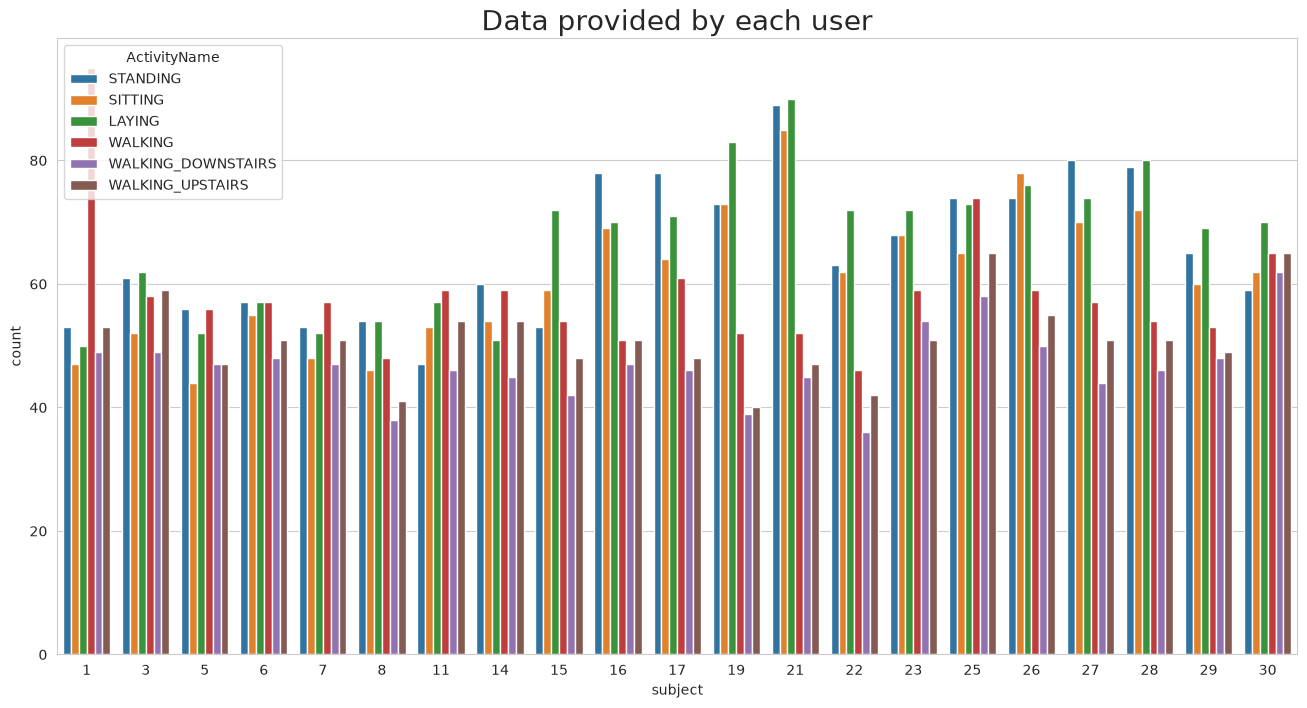

In [8]:
import matplotlib as mlt
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Dejavu Sans'

plt.figure(figsize=(16,8))
plt.title('Data provided by each user', fontsize=20)
sns.countplot(x='subject',hue='ActivityName', data = train)
plt.show()

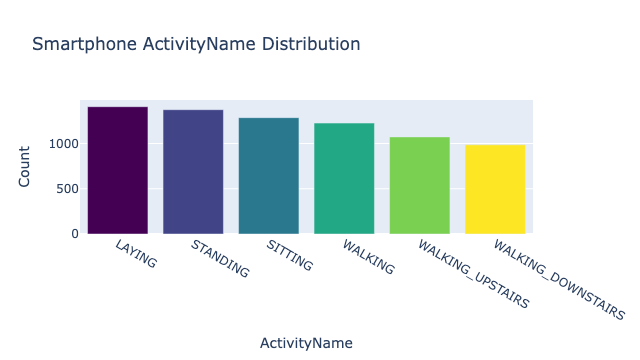

In [9]:
import plotly
import plotly.graph_objects as go
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot

label_counts = train['ActivityName'].value_counts()

n = label_counts.shape[0]
colormap = plt.get_cmap('viridis')
colors = [mlt.colors.to_hex(colormap(col)) for col in np.arange(0, 1.01, 1/(n-1))]

data = go.Bar(x = label_counts.index,
              y = label_counts,
              marker = dict(color = colors))

layout = go.Layout(title = 'Smartphone ActivityName Distribution',
                   xaxis = dict(title = 'ActivityName'),
                   yaxis = dict(title = 'Count'))

fig = go.Figure(data=[data], layout=layout)
fig.show()



3. Stationary and Moving activities are completely different

/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: invalid value encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/

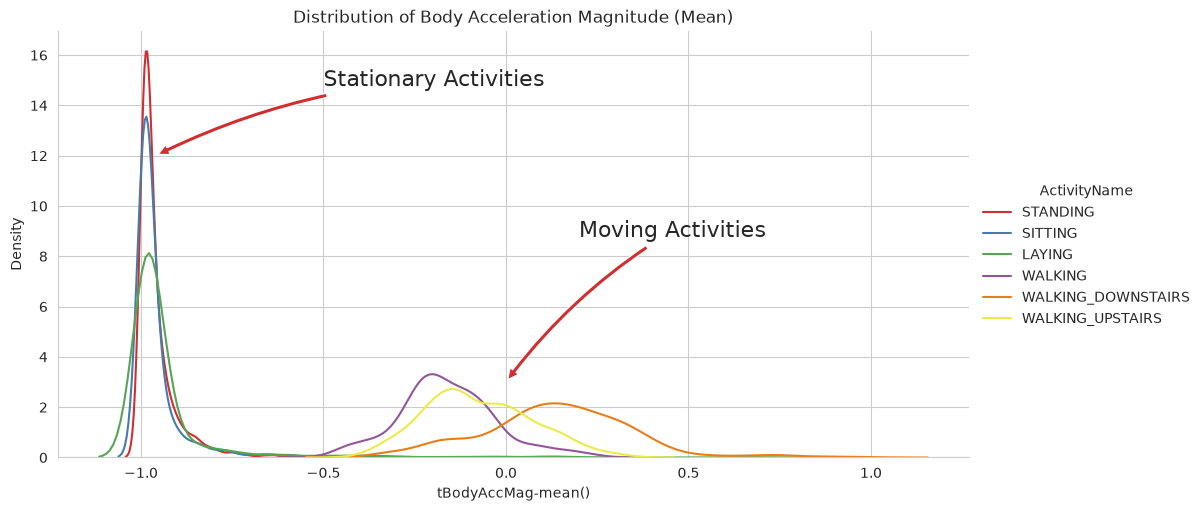

In [10]:
sns.set_palette("Set1", desat=0.80)
facetgrid = sns.FacetGrid(train, hue='ActivityName', height=5, aspect=2)
facetgrid.map(sns.kdeplot, 'tBodyAccMag-mean()', fill=False).add_legend()

plt.annotate("Stationary Activities", xy=(-0.960,12), xytext=(-0.5, 15), size=16,
             va='center', ha='left',
             arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1"))

plt.annotate("Moving Activities", xy=(0,3), xytext=(0.2, 9), size=16,
             va='center', ha='left',
             arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1"))

plt.title("Distribution of Body Acceleration Magnitude (Mean)")
plt.show()


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: invalid value encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: divide by zero encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/_kde.py:741: RuntimeWarning: overflow encountered in vecdot
  self._neff = 1/np.vecdot(self.weights, self.weights)
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/scipy/stats/

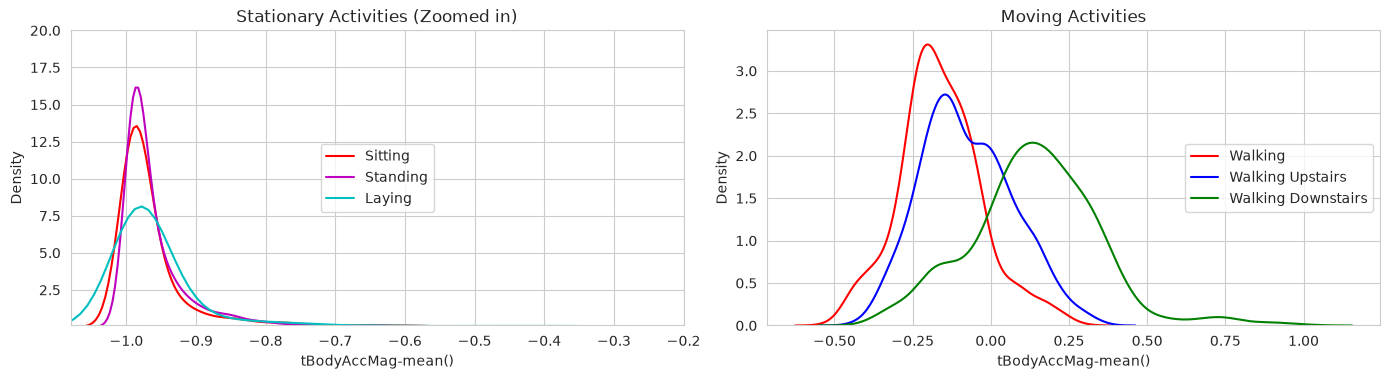

In [11]:

mag_col = 'tBodyAccMag-mean()'

df1 = train[train['Activity']==1]  # Walking
df2 = train[train['Activity']==2]  # Walking Upstairs
df3 = train[train['Activity']==3]  # Walking Downstairs
df4 = train[train['Activity']==4]  # Sitting
df5 = train[train['Activity']==5]  # Standing
df6 = train[train['Activity']==6]  # Laying

plt.figure(figsize=(14,7))

plt.subplot(2,2,1)
plt.title('Stationary Activities (Zoomed in)')
sns.kdeplot(df4[mag_col], color='r', fill=False, label='Sitting')
sns.kdeplot(df5[mag_col], color='m', fill=False, label='Standing')
sns.kdeplot(df6[mag_col], color='c', fill=False, label='Laying')
plt.axis([-1.08, -0.2, 0.1, 20])
plt.legend(loc='center')

plt.subplot(2,2,2)
plt.title('Moving Activities')
sns.kdeplot(df1[mag_col], color='red', fill=False, label='Walking')
sns.kdeplot(df2[mag_col], color='blue', fill=False, label='Walking Upstairs')
sns.kdeplot(df3[mag_col], color='green', fill=False, label='Walking Downstairs')
plt.legend(loc='center right')

plt.tight_layout()
plt.show()

4. Magnitude of an acceleration can saperate it well

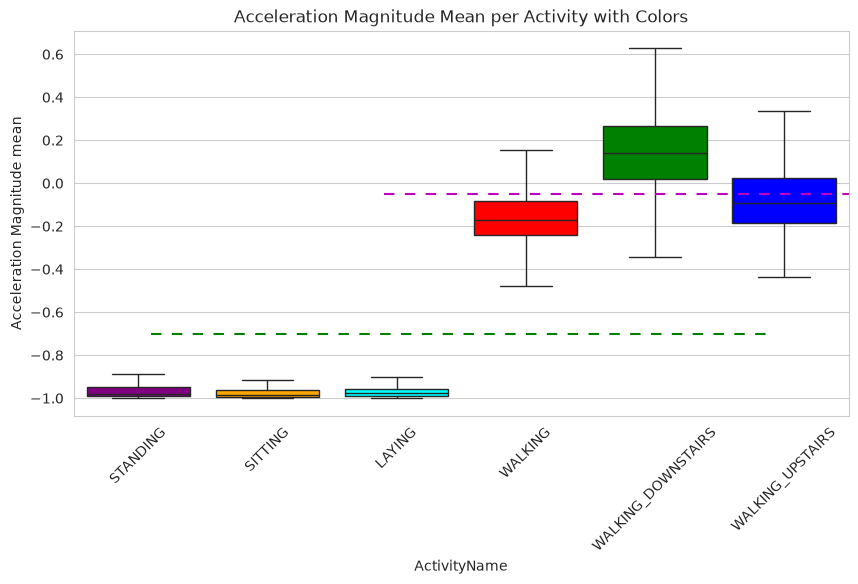

In [12]:
plt.figure(figsize=(10,5))

palette_colors = {
    'WALKING': 'red',
    'WALKING_UPSTAIRS': 'blue',
    'WALKING_DOWNSTAIRS': 'green',
    'SITTING': 'orange',
    'STANDING': 'purple',
    'LAYING': 'cyan'
}

sns.boxplot(
    x='ActivityName',
    y='tBodyAccMag-mean()',
    showfliers=False,
    saturation=1,
    palette=palette_colors,
    data=train,
    hue='ActivityName', 
    legend=False 
)

plt.ylabel('Acceleration Magnitude mean')
plt.axhline(y=-0.7, xmin=0.1, xmax=0.9, dashes=(5,5), c='g')
plt.axhline(y=-0.05, xmin=0.4, dashes=(5,5), c='m')
plt.xticks(rotation=45)
plt.title('Acceleration Magnitude Mean per Activity with Colors')
plt.show()



* When tAccMean is less than -0.8, the activity is likely Standing, Sitting, or Laying.
* When tAccMean is greater than -0.6, the activity is likely Walking, Walking Downstairs, or Walking Upstairs.
*  When tAccMean is above 0.0, the activity is most likely Walking Downstairs.
*   Using these thresholds, we can correctly classify approximately 75% of activity labels, though some misclassifications may occur.




5. Position of GravityAccelerationComponants also matters

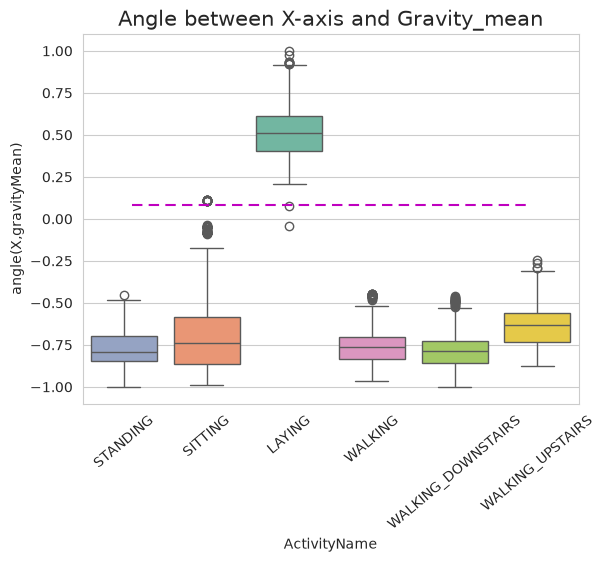

In [13]:
acts = train['ActivityName'].astype('category')
palette = dict(zip(acts.cat.categories, sns.color_palette("Set2", n_colors=acts.cat.categories.size)))

sns.boxplot(
    data=train,
    x='ActivityName',
    y='angle(X,gravityMean)',
    hue='ActivityName',
    palette=palette,
    dodge=False,
    legend=False
)
plt.axhline(y=0.08, xmin=0.1, xmax=0.9, c='m', dashes=(5,3))
plt.title('Angle between X-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation=40)
plt.show()




*   If angleXgravityMean exceeds 0, the activity can be determined as Laying.
*  Thus, all data points for the Laying activity can be classified using a straightforward if-else statement.



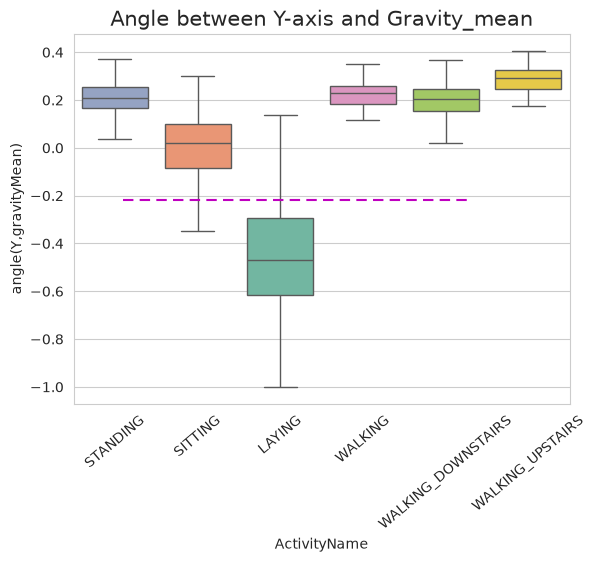

In [14]:
acts = train['ActivityName'].astype('category')
palette = dict(zip(acts.cat.categories, sns.color_palette("Set2", n_colors=acts.cat.categories.size)))

sns.boxplot(
    data=train,
    x='ActivityName',
    y='angle(Y,gravityMean)',
    hue='ActivityName',
    palette=palette,
    dodge=False,
    showfliers=False,
    legend=False
)

plt.title('Angle between Y-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation=40)
plt.axhline(y=-0.22, xmin=0.1, xmax=0.8, dashes=(5,3), c='m')
plt.show()


## **Apply t-sne on the data**


In [15]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:

def perform_tsne(X_data, y_data, perplexities, n_iter=1000, img_name_prefix='t-sne'):

    for index,perplexity in enumerate(perplexities):
   
        print('\nperforming tsne with perplexity {} and with {} iterations at max'.format(perplexity, n_iter))
        X_reduced = TSNE(verbose=2, perplexity=perplexity).fit_transform(X_data)
        print('Done..')

        print('Creating plot for this t-sne visualization..')
        df = pd.DataFrame({'x':X_reduced[:,0], 'y':X_reduced[:,1] ,'label':y_data})


        sns.lmplot(data=df, x='x', y='y', hue='label', fit_reg=False, height=8,\
                   palette="Set1",markers=['^','v','s','o', '1','2'])
        plt.title("perplexity : {} and max_iter : {}".format(perplexity, n_iter))
        img_name = img_name_prefix + '_perp_{}_iter_{}.png'.format(perplexity, n_iter)
        print('saving this plot as image in present working directory...')
        plt.savefig(img_name)
        plt.show()
        print('Done')


performing tsne with perplexity 2 and with 1000 iterations at max
[t-SNE] Computing 7 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.011s...
[t-SNE] Computed neighbors for 7352 samples in 0.168s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.597443
[t-SNE] Computed conditional probabilities in 0.012s


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

[t-SNE] Iteration 50: error = 119.3450775, gradient norm = 0.0456450 (50 iterations in 0.716s)
[t-SNE] Iteration 100: error = 105.0340881, gradient norm = 0.0250204 (50 iterations in 0.460s)
[t-SNE] Iteration 150: error = 99.7559433, gradient norm = 0.0175239 (50 iterations in 0.426s)
[t-SNE] Iteration 200: error = 96.7353973, gradient norm = 0.0137769 (50 iterations in 0.417s)
[t-SNE] Iteration 250: error = 94.6223450, gradient norm = 0.0104919 (50 iterations in 0.411s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 94.622345
[t-SNE] Iteration 300: error = 4.2684107, gradient norm = 0.0181438 (50 iterations in 0.409s)
[t-SNE] Iteration 350: error = 3.3592458, gradient norm = 0.0193083 (50 iterations in 0.413s)
[t-SNE] Iteration 400: error = 2.8627787, gradient norm = 0.0154255 (50 iterations in 0.414s)
[t-SNE] Iteration 450: error = 2.5695286, gradient norm = 0.0132868 (50 iterations in 0.421s)
[t-SNE] Iteration 500: error = 2.3681121, gradient norm = 0.0114292 (5

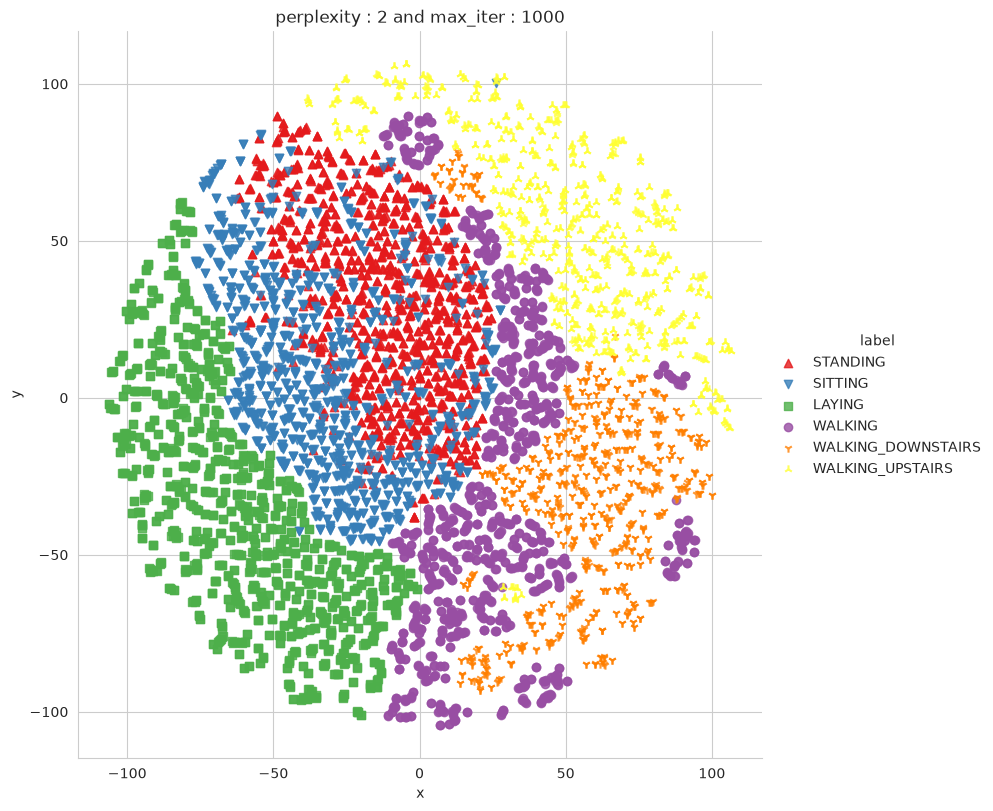

Done

performing tsne with perplexity 5 and with 1000 iterations at max
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.007s...
[t-SNE] Computed neighbors for 7352 samples in 0.134s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.961446
[t-SNE] Computed conditional probabilities in 0.015s


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

[t-SNE] Iteration 50: error = 107.1300049, gradient norm = 0.0390418 (50 iterations in 0.872s)
[t-SNE] Iteration 100: error = 95.6724930, gradient norm = 0.0145839 (50 iterations in 0.484s)
[t-SNE] Iteration 150: error = 92.4221954, gradient norm = 0.0096240 (50 iterations in 0.449s)
[t-SNE] Iteration 200: error = 90.7471542, gradient norm = 0.0065488 (50 iterations in 0.439s)
[t-SNE] Iteration 250: error = 89.7055511, gradient norm = 0.0055891 (50 iterations in 0.464s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 89.705551
[t-SNE] Iteration 300: error = 3.7112632, gradient norm = 0.0166995 (50 iterations in 0.486s)
[t-SNE] Iteration 350: error = 2.9562426, gradient norm = 0.0166849 (50 iterations in 0.449s)
[t-SNE] Iteration 400: error = 2.5385427, gradient norm = 0.0158215 (50 iterations in 0.415s)
[t-SNE] Iteration 450: error = 2.2874756, gradient norm = 0.0133855 (50 iterations in 0.426s)
[t-SNE] Iteration 500: error = 2.1233764, gradient norm = 0.0117770 (50

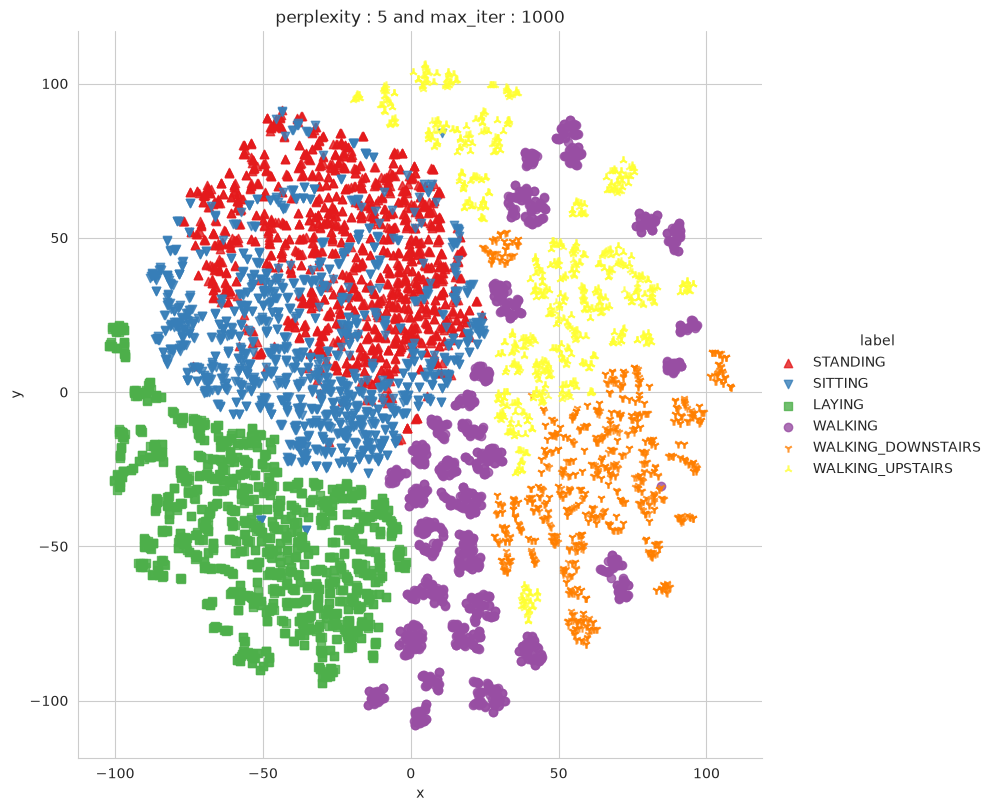

Done

performing tsne with perplexity 10 and with 1000 iterations at max
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.006s...
[t-SNE] Computed neighbors for 7352 samples in 0.151s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.133827
[t-SNE] Computed conditional probabilities in 0.028s


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

[t-SNE] Iteration 50: error = 97.8917542, gradient norm = 0.0358168 (50 iterations in 0.852s)
[t-SNE] Iteration 100: error = 88.9886932, gradient norm = 0.0097477 (50 iterations in 0.501s)
[t-SNE] Iteration 150: error = 86.7865219, gradient norm = 0.0063453 (50 iterations in 0.490s)
[t-SNE] Iteration 200: error = 85.7554169, gradient norm = 0.0041687 (50 iterations in 0.474s)
[t-SNE] Iteration 250: error = 85.1537018, gradient norm = 0.0035170 (50 iterations in 0.472s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 85.153702
[t-SNE] Iteration 300: error = 3.2536924, gradient norm = 0.0156881 (50 iterations in 0.452s)
[t-SNE] Iteration 350: error = 2.6055593, gradient norm = 0.0150445 (50 iterations in 0.427s)
[t-SNE] Iteration 400: error = 2.2683215, gradient norm = 0.0139939 (50 iterations in 0.417s)
[t-SNE] Iteration 450: error = 2.0601857, gradient norm = 0.0130046 (50 iterations in 0.466s)
[t-SNE] Iteration 500: error = 1.9230887, gradient norm = 0.0115857 (50 

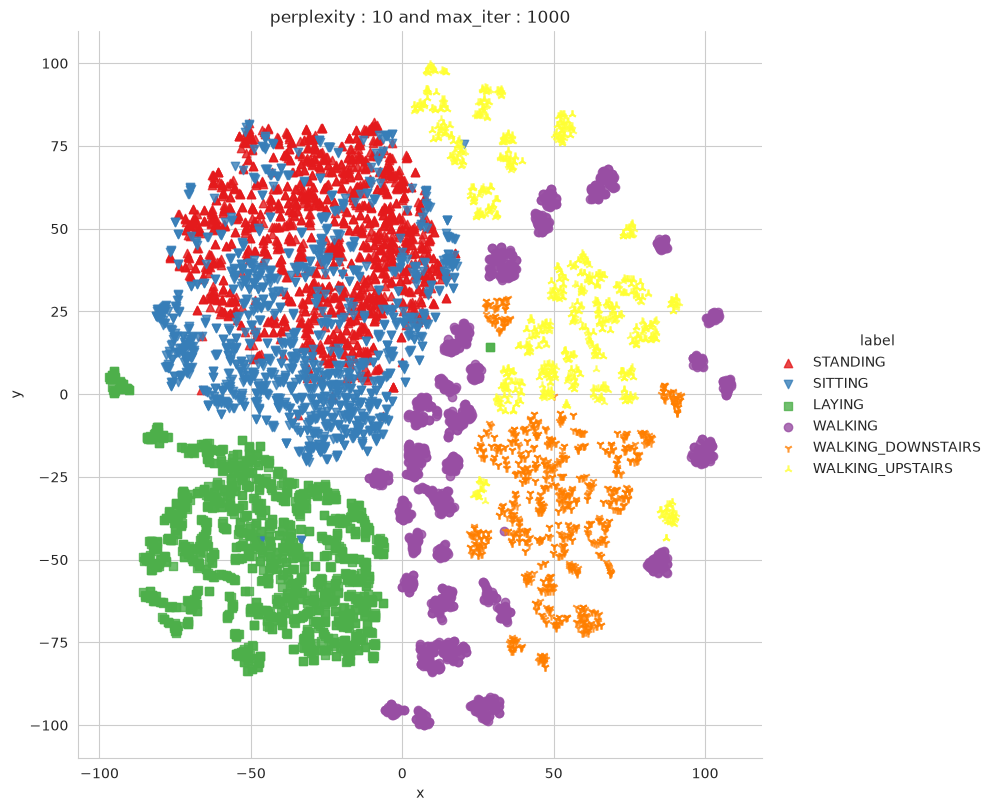

Done

performing tsne with perplexity 20 and with 1000 iterations at max
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.006s...
[t-SNE] Computed neighbors for 7352 samples in 0.199s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.274336
[t-SNE] Computed conditional probabilities in 0.076s


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

[t-SNE] Iteration 50: error = 89.2839737, gradient norm = 0.0308618 (50 iterations in 0.879s)
[t-SNE] Iteration 100: error = 82.9941711, gradient norm = 0.0079859 (50 iterations in 0.566s)
[t-SNE] Iteration 150: error = 81.6020050, gradient norm = 0.0047576 (50 iterations in 0.538s)
[t-SNE] Iteration 200: error = 81.0317764, gradient norm = 0.0031975 (50 iterations in 0.550s)
[t-SNE] Iteration 250: error = 80.7038345, gradient norm = 0.0025887 (50 iterations in 0.541s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.703835
[t-SNE] Iteration 300: error = 2.8007817, gradient norm = 0.0146712 (50 iterations in 0.502s)
[t-SNE] Iteration 350: error = 2.2540040, gradient norm = 0.0134214 (50 iterations in 0.469s)
[t-SNE] Iteration 400: error = 1.9891527, gradient norm = 0.0122150 (50 iterations in 0.519s)
[t-SNE] Iteration 450: error = 1.8309462, gradient norm = 0.0112881 (50 iterations in 0.464s)
[t-SNE] Iteration 500: error = 1.7249460, gradient norm = 0.0105689 (50 

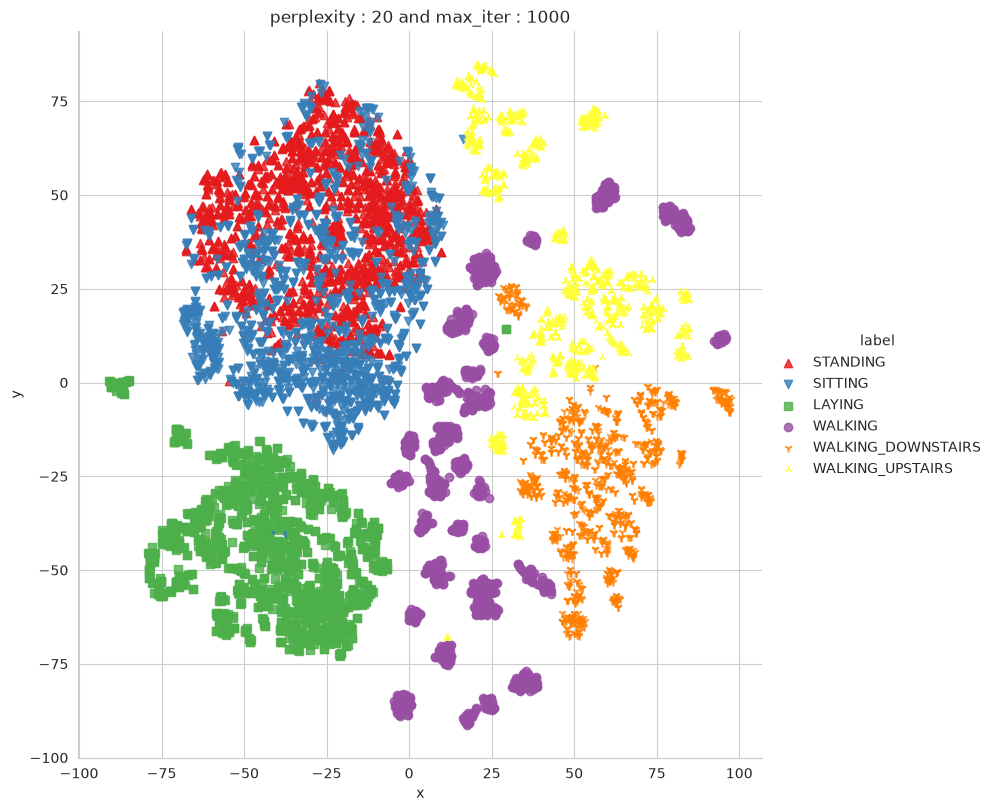

Done

performing tsne with perplexity 50 and with 1000 iterations at max
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.006s...
[t-SNE] Computed neighbors for 7352 samples in 0.253s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.437672
[t-SNE] Computed conditional probabilities in 0.194s


/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/HAR_TF/lib/python3.12/site-packages/sklearn/decomposition/_base.py:158: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

[t-SNE] Iteration 50: error = 78.8856049, gradient norm = 0.0260784 (50 iterations in 1.185s)
[t-SNE] Iteration 100: error = 75.2732086, gradient norm = 0.0053240 (50 iterations in 0.735s)
[t-SNE] Iteration 150: error = 74.5434952, gradient norm = 0.0031001 (50 iterations in 0.707s)
[t-SNE] Iteration 200: error = 74.2509918, gradient norm = 0.0022444 (50 iterations in 0.705s)
[t-SNE] Iteration 250: error = 74.0905457, gradient norm = 0.0018348 (50 iterations in 0.784s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.090546
[t-SNE] Iteration 300: error = 2.2387724, gradient norm = 0.0130104 (50 iterations in 0.654s)
[t-SNE] Iteration 350: error = 1.8231246, gradient norm = 0.0111799 (50 iterations in 0.551s)
[t-SNE] Iteration 400: error = 1.6404352, gradient norm = 0.0098647 (50 iterations in 0.551s)
[t-SNE] Iteration 450: error = 1.5371599, gradient norm = 0.0089224 (50 iterations in 0.552s)
[t-SNE] Iteration 500: error = 1.4708152, gradient norm = 0.0081683 (50 

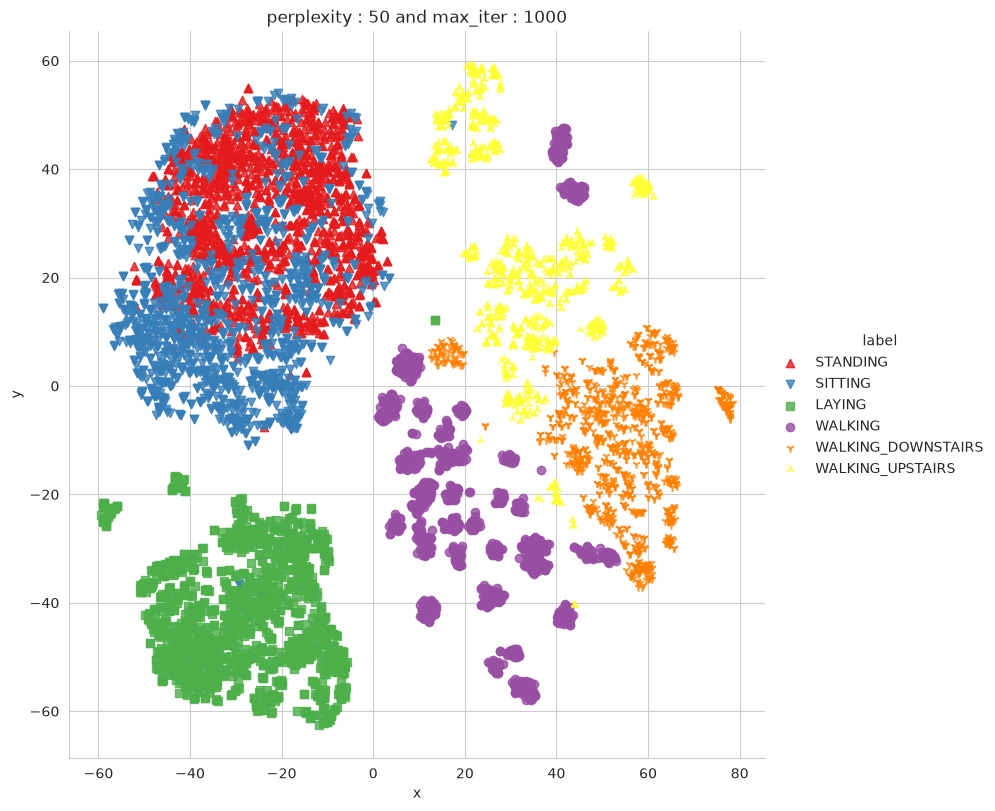

Done


In [17]:
X_pre_tsne = train.drop(
    ['subject', 'Activity', 'ActivityName'],
    axis=1
).values

y_pre_tsne = train['ActivityName']

perform_tsne(
    X_data=X_pre_tsne,
    y_data=y_pre_tsne,
    perplexities=[2, 5, 10, 20, 50]
)

In [18]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from datetime import datetime

from sklearn import linear_model
from sklearn import metrics

from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

Loading Data form File

In [19]:
train.head(2)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,ActivityName
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,5,STANDING


# Making Data for Model

In [20]:

X_train = train.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_train = train['ActivityName']

X_test = test.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_test = test['ActivityName']


print('X_train and y_train : ({}, {})'.format(X_train.shape, y_train.shape))
print('X_test  and y_test  : ({}, {})'.format(X_test.shape, y_test.shape))


X_train and y_train : ((7352, 561), (7352,))
X_test  and y_test  : ((2947, 561), (2947,))


Let's start modeling with our Dataset

In [22]:
labels=['LAYING', 'SITTING','STANDING','WALKING','WALKING_DOWNSTAIRS','WALKING_UPSTAIRS']


Let's make a function to plot the confusion matrix

In [23]:
plt.rcParams["font.family"] = 'DejaVu Sans'

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


In [24]:
from datetime import datetime
def perform_model(model, X_train, y_train, X_test, y_test, class_labels, cm_normalize=True, \
                 print_cm=True, cm_cmap=plt.cm.Greens):


    results = dict()

    train_start_time = datetime.now()
    print('training the model..')
    model.fit(X_train, y_train)
    print('Done....!\n')
    train_end_time = datetime.now()
    results['training_time'] =  train_end_time - train_start_time
    print('==> training time:- {}\n'.format(results['training_time']))

    print('Predicting test data')
    test_start_time = datetime.now()
    y_pred = model.predict(X_test)
    test_end_time = datetime.now()
    print('Done....!\n')
    results['testing_time'] = test_end_time - test_start_time
    print('==> testing time:- {}\n'.format(results['testing_time']))
    results['predicted'] = y_pred


    accuracy = metrics.accuracy_score(y_true=y_test, y_pred=y_pred)
    
    results['accuracy'] = accuracy
    print('==> Accuracy:- {}\n'.format(accuracy))

    cm = metrics.confusion_matrix(y_test, y_pred)
    results['confusion_matrix'] = cm
    if print_cm:
        print('\n ********Confusion Matrix********')
        print('\n {}'.format(cm))


    plt.figure(figsize=(6,6))
    plt.grid(False) 
    plot_confusion_matrix(cm, classes=class_labels, normalize=True, title='Normalized confusion matrix', cmap = cm_cmap)
    plt.show()

    print('****************| Classifiction Report |****************')
    classification_report = metrics.classification_report(y_test, y_pred)


    results['classification_report'] = classification_report
    print(classification_report)

    results['model'] = model

    return results


Make function to print the gridsearch Parameters

In [25]:
def print_grid_search_attributes(model):
    
    print('\n\n==> Best Estimator:')
    print('\t{}\n'.format(model.best_estimator_))

    print('\n==> Best parameters:')
    print('\tParameters of best estimator : {}'.format(model.best_params_))

    print('\n==> No. of CrossValidation sets:')
    print('\tTotal numbre of cross validation sets: {}'.format(model.n_splits_))

    print('\n==> Best Score:')
    print('\tAverage Cross Validate scores of best estimator : {}'.format(model.best_score_))




1. Logistic Regression with Grid Search

training the model..
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Done....!

==> training time:- 0:00:07.458392

Predicting test data
Done....!

==> testing time:- 0:00:00.002017

==> Accuracy:- 0.9653885307091958


 ********Confusion Matrix********

 [[537   0   0   0   0   0]
 [  3 435  50   0   0   3]
 [  0  13 519   0   0   0]
 [  0   0   0 492   3   1]
 [  0   0   0   3 408   9]
 [  0   0   0  15   2 454]]


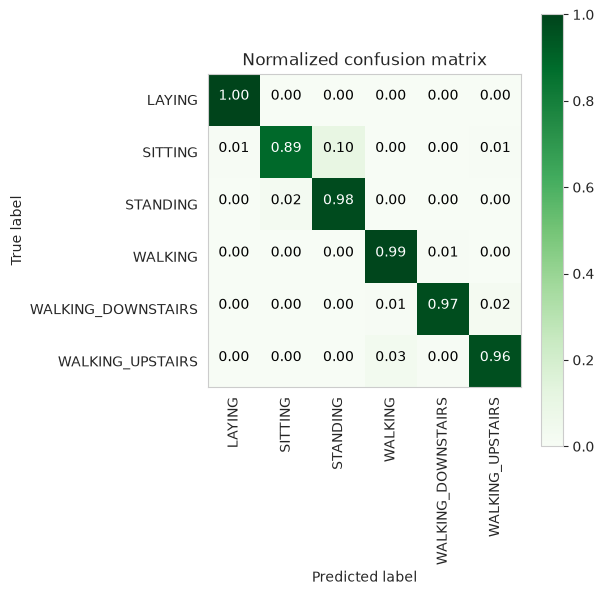

****************| Classifiction Report |****************
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.97      0.89      0.93       491
          STANDING       0.91      0.98      0.94       532
           WALKING       0.96      0.99      0.98       496
WALKING_DOWNSTAIRS       0.99      0.97      0.98       420
  WALKING_UPSTAIRS       0.97      0.96      0.97       471

          accuracy                           0.97      2947
         macro avg       0.97      0.96      0.97      2947
      weighted avg       0.97      0.97      0.97      2947



==> Best Estimator:
	LogisticRegression(C=30, max_iter=1000, penalty='l2')


==> Best parameters:
	Parameters of best estimator : {'C': 30, 'penalty': 'l2'}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 3

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9434182910210188


In [26]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=ConvergenceWarning)

X_train_lr = X_train.to_numpy()
X_test_lr = X_test.to_numpy()

parameters = {
    'C': [0.01, 0.1, 1, 10, 20, 30],
    'penalty': ['l2']
}

log_reg = linear_model.LogisticRegression(max_iter=1000)

log_reg_grid = GridSearchCV(
    log_reg,
    param_grid=parameters,
    cv=3,
    verbose=1,
    n_jobs=-1
)

log_reg_grid_results = perform_model(
    log_reg_grid,
    X_train_lr,
    y_train,
    X_test_lr,
    y_test,
    class_labels=labels
)

print_grid_search_attributes(log_reg_grid_results['model'])


2. Linear SVC with GridSearch

training the model..
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Done....!

==> training time:- 0:00:09.668839

Predicting test data
Done....!

==> testing time:- 0:00:00.002250

==> Accuracy:- 0.9667458432304038


 ********Confusion Matrix********

 [[537   0   0   0   0   0]
 [  2 428  58   0   0   3]
 [  0   9 522   1   0   0]
 [  0   0   0 496   0   0]
 [  0   0   0   3 412   5]
 [  0   0   0  17   0 454]]


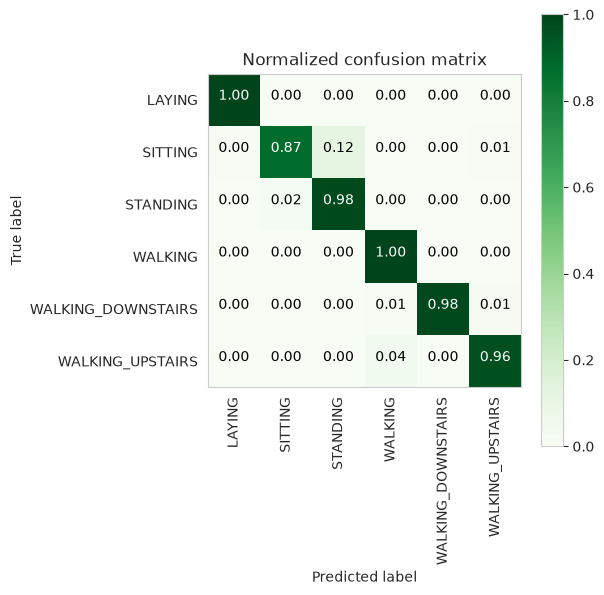

****************| Classifiction Report |****************
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.98      0.87      0.92       491
          STANDING       0.90      0.98      0.94       532
           WALKING       0.96      1.00      0.98       496
WALKING_DOWNSTAIRS       1.00      0.98      0.99       420
  WALKING_UPSTAIRS       0.98      0.96      0.97       471

          accuracy                           0.97      2947
         macro avg       0.97      0.97      0.97      2947
      weighted avg       0.97      0.97      0.97      2947



==> Best Estimator:
	LinearSVC(C=0.5, tol=5e-05)


==> Best parameters:
	Parameters of best estimator : {'C': 0.5}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9420643090682909


In [27]:
parameters = {'C':[0.125, 0.5, 1, 2, 8, 16]}

lr_svc = LinearSVC(tol=0.00005)

lr_svc_grid = GridSearchCV(
    lr_svc,
    param_grid=parameters,
    n_jobs=-1,
    verbose=1
)

lr_svc_grid_results = perform_model(
    lr_svc_grid,
    X_train.values,
    y_train,
    X_test.values,
    y_test,
    class_labels=labels
)

print_grid_search_attributes(lr_svc_grid_results['model'])


3. Kernel SVM with GridSearch

training the model..
Done....!

==> training time:- 0:01:06.585755

Predicting test data
Done....!

==> testing time:- 0:00:00.850863

==> Accuracy:- 0.9626739056667798


 ********Confusion Matrix********

 [[537   0   0   0   0   0]
 [  0 441  48   0   0   2]
 [  0  12 520   0   0   0]
 [  0   0   0 489   2   5]
 [  0   0   0   4 397  19]
 [  0   0   0  17   1 453]]


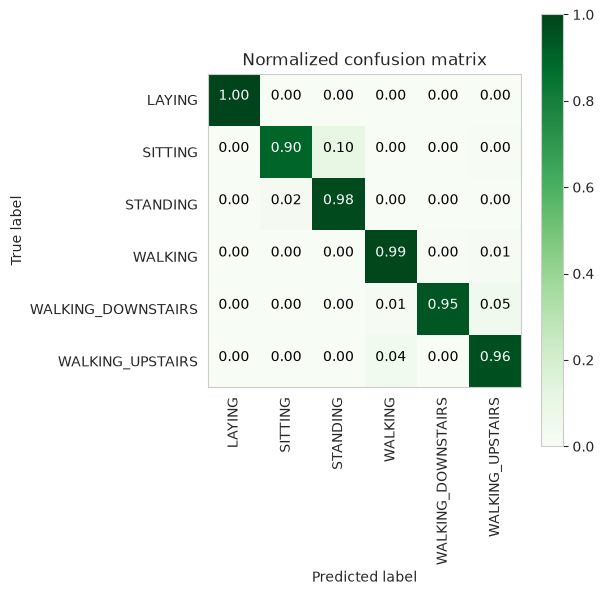

****************| Classifiction Report |****************
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.97      0.90      0.93       491
          STANDING       0.92      0.98      0.95       532
           WALKING       0.96      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.95      0.97       420
  WALKING_UPSTAIRS       0.95      0.96      0.95       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



==> Best Estimator:
	SVC(C=16, gamma=0.0078125)


==> Best parameters:
	Parameters of best estimator : {'C': 16, 'gamma': 0.0078125}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.9447834551903698


In [28]:
parameters = {
    'C': [2, 8, 16],
    'gamma': [0.0078125, 0.125, 2]
}

rbf_svm = SVC(kernel='rbf')

rbf_svm_grid = GridSearchCV(
    rbf_svm,
    param_grid=parameters,
    n_jobs=-1
)

rbf_svm_grid_results = perform_model(
    rbf_svm_grid,
    X_train.values,
    y_train,
    X_test.values,
    y_test,
    class_labels=labels
)

print_grid_search_attributes(rbf_svm_grid_results['model'])


4. Decision Trees with GridSearchCV

training the model..
Done....!

==> training time:- 0:00:05.596863

Predicting test data
Done....!

==> testing time:- 0:00:00.001928

==> Accuracy:- 0.8622327790973872


 ********Confusion Matrix********

 [[537   0   0   0   0   0]
 [  0 386 105   0   0   0]
 [  0  93 439   0   0   0]
 [  0   0   0 471  17   8]
 [  0   0   0  20 339  61]
 [  0   0   0  78  24 369]]


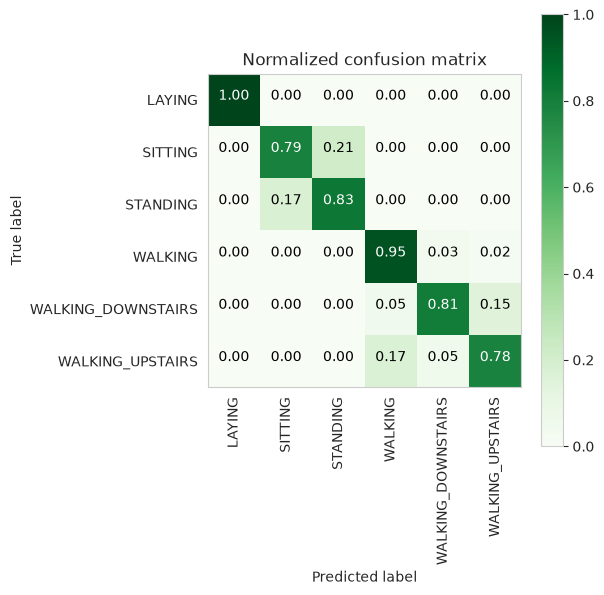

****************| Classifiction Report |****************
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.81      0.79      0.80       491
          STANDING       0.81      0.83      0.82       532
           WALKING       0.83      0.95      0.88       496
WALKING_DOWNSTAIRS       0.89      0.81      0.85       420
  WALKING_UPSTAIRS       0.84      0.78      0.81       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



==> Best Estimator:
	DecisionTreeClassifier(max_depth=np.int64(7), random_state=42)


==> Best parameters:
	Parameters of best estimator : {'max_depth': np.int64(7)}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Score:
	Average Cross Validate scores of best estimator : 0.8497074043757543


In [29]:
parameters = {'max_depth': np.arange(3, 10, 2)}

dt = DecisionTreeClassifier(random_state=42)

dt_grid = GridSearchCV(
    dt,
    param_grid=parameters,
    n_jobs=-1
)

dt_grid_results = perform_model(
    dt_grid,
    X_train.values,
    y_train,
    X_test.values,
    y_test,
    class_labels=labels
)

print_grid_search_attributes(dt_grid_results['model'])

5. Random Forest Classifier with GridSearch

training the model..
Done....!

==> training time:- 0:02:39.380343

Predicting test data
Done....!

==> testing time:- 0:00:00.022975

==> Accuracy:- 0.9144893111638955


 ********Confusion Matrix********

 [[537   0   0   0   0   0]
 [  0 415  76   0   0   0]
 [  0  37 495   0   0   0]
 [  0   0   0 484  10   2]
 [  0   0   0  35 340  45]
 [  0   0   0  41   6 424]]


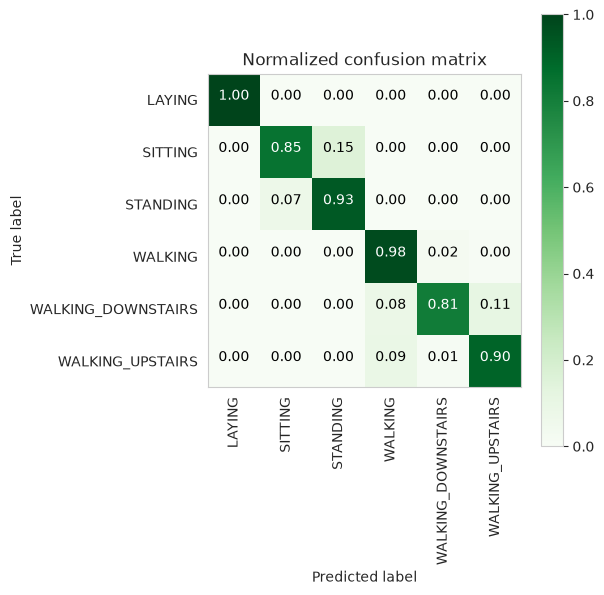

****************| Classifiction Report |****************
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.92      0.85      0.88       491
          STANDING       0.87      0.93      0.90       532
           WALKING       0.86      0.98      0.92       496
WALKING_DOWNSTAIRS       0.96      0.81      0.88       420
  WALKING_UPSTAIRS       0.90      0.90      0.90       471

          accuracy                           0.91      2947
         macro avg       0.92      0.91      0.91      2947
      weighted avg       0.92      0.91      0.91      2947



==> Best Estimator:
	RandomForestClassifier(max_depth=np.int64(7), n_estimators=np.int64(170),
                       random_state=42)


==> Best parameters:
	Parameters of best estimator : {'max_depth': np.int64(7), 'n_estimators': np.int64(170)}

==> No. of CrossValidation sets:
	Total numbre of cross validation sets: 5

==> Best Scor

In [30]:
params = {
    'n_estimators': np.arange(10, 201, 20),
    'max_depth': np.arange(3, 15, 2)
}
rfc = RandomForestClassifier(random_state=42)

rfc_grid = GridSearchCV(
    rfc,
    param_grid=params,
    n_jobs=-1
)

rfc_grid_results = perform_model(
    rfc_grid,
    X_train.values,
    y_train,
    X_test.values,
    y_test,
    class_labels=labels
)

print_grid_search_attributes(rfc_grid_results['model'])


7. Comparing all models

In [31]:
X_test.columns = X_train.columns          
print("Duplicate columns left in X_test:", X_test.columns.duplicated().sum())   

Duplicate columns left in X_test: 84


In [32]:
def make_unique(cols):
    seen, out = {}, []
    for c in cols:
        if c in seen:
            seen[c] += 1
            out.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            out.append(c)
    return out

X_train.columns = make_unique(X_train.columns)
X_test.columns = X_train.columns

In [33]:
# ***************** Accuracy, Error, Precision, Recall, F1 and Confusion Matrix *****************
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

all_results = {
    'Logistic Regression': log_reg_grid_results,
    'Linear SVC':          lr_svc_grid_results,
    'rbf SVM classifier':  rbf_svm_grid_results,
    'DecisionTree':        dt_grid_results,
    'Random Forest':       rfc_grid_results,
}

rows = []
preds = {}
for name, res in all_results.items():
    y_pred = res['model'].predict(X_test)          
    preds[name] = y_pred
    acc = accuracy_score(y_test, y_pred) * 100
    rows.append([
        name,
        acc,
        100 - acc,
        precision_score(y_test, y_pred, average='macro') * 100,
        recall_score(y_test, y_pred, average='macro') * 100,
        f1_score(y_test, y_pred, average='macro') * 100,
    ])

metrics_df = pd.DataFrame(rows, columns=['Model', 'Accuracy %', 'Error %',
                                         'Precision %', 'Recall %', 'F1-score %'])

# ---- 1. Accuracy and Error  ----
print('\n                     Accuracy     Error')
print('                     ----------   --------')
for _, r in metrics_df.iterrows():
    print('{:<20}: {:.04}%       {:.04}%'.format(r['Model'], r['Accuracy %'], r['Error %']))

# ---- 2. Precision, Recall, F1  ----
print('\n                     Precision    Recall       F1-score')
print('                     ----------   ----------   ----------')
for _, r in metrics_df.iterrows():
    print('{:<20}: {:<10.2f}%  {:<10.2f}%  {:<10.2f}%'.format(
        r['Model'], r['Precision %'], r['Recall %'], r['F1-score %']))




                     Accuracy     Error
                     ----------   --------
Logistic Regression : 96.54%       3.461%
Linear SVC          : 96.67%       3.325%
rbf SVM classifier  : 96.27%       3.733%
DecisionTree        : 86.22%       13.78%
Random Forest       : 91.45%       8.551%

                     Precision    Recall       F1-score
                     ----------   ----------   ----------
Logistic Regression : 96.71     %  96.48     %  96.54     %
Linear SVC          : 96.96     %  96.63     %  96.70     %
rbf SVM classifier  : 96.43     %  96.14     %  96.23     %
DecisionTree        : 86.25     %  85.86     %  85.93     %
Random Forest       : 91.74     %  91.02     %  91.18     %


## **Applying LSTM Models on Raw Data**

In [34]:

import pandas as pd
import numpy as np

from keras import backend as K
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout 
from keras.layers import BatchNormalization
from keras.regularizers import L1L2

In [35]:
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [36]:

epochs = 30
batch_size = 16
n_hidden = 32

In [37]:

def _count_classes(y):
    return len(set([tuple(category) for category in y]))

In [54]:
import os
import numpy as np
from tensorflow.keras.utils import to_categorical

BASE_PATH = 'UCI_HAR_Dataset'
TIMESTEPS = 128

SIGNAL_FILES = [
    'total_acc_x_{}.txt','total_acc_y_{}.txt','total_acc_z_{}.txt',
    'body_acc_x_{}.txt','body_acc_y_{}.txt','body_acc_z_{}.txt',
    'body_gyro_x_{}.txt','body_gyro_y_{}.txt','body_gyro_z_{}.txt'
]

def _fast_load(path, timesteps=TIMESTEPS):
    arr = np.genfromtxt(path)
    if arr.ndim == 1:
        n = arr.size // timesteps
        arr = arr[:n*timesteps].reshape(n, timesteps)
    elif arr.ndim == 2 and arr.shape[1] != timesteps:
        flat = arr.ravel()
        n = flat.size // timesteps
        arr = flat[:n*timesteps].reshape(n, timesteps)
    return arr

def _load_signals(subset):
    folder = os.path.join(BASE_PATH, subset, 'Inertial Signals')
    arrays = [_fast_load(os.path.join(folder, f.format(subset))) for f in SIGNAL_FILES]
    min_rows = min(a.shape[0] for a in arrays)
    arrays = [a[:min_rows] for a in arrays]
    return np.stack(arrays, axis=2)

def _load_labels(subset):
    p = os.path.join(BASE_PATH, subset, f'y_{subset}.txt')
    return np.genfromtxt(p).astype(int)

def load_data():
    X_train = _load_signals('train')
    X_test  = _load_signals('test')
    y_train = _load_labels('train')[:X_train.shape[0]]
    y_test  = _load_labels('test')[:X_test.shape[0]]
    y_train = (y_train - 1).astype(int)
    y_test  = (y_test - 1).astype(int)
    return X_train, X_test, to_categorical(y_train), to_categorical(y_test)

X_train, X_test, Y_train, Y_test = load_data()

In [55]:
timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
n_classes = _count_classes(Y_train)

print(timesteps)
print(input_dim)
print(len(X_train))

128
9
7352


In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import L1L2
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)


subjects_train = np.loadtxt(os.path.join(BASE_PATH, 'train', 'subject_train.txt'), dtype=int)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss.split(X_train, Y_train.argmax(axis=1), groups=subjects_train))
X_tr,  Y_tr  = X_train[tr_idx], Y_train[tr_idx]
X_val, Y_val = X_train[val_idx], Y_train[val_idx]

timesteps, input_dim, n_classes = X_tr.shape[1], X_tr.shape[2], 6
reg = L1L2(0.01, 0.01)
lstm_labels = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
lstm_rows = []

def evaluate_lstm(name, model):
    y_true = np.argmax(Y_test, axis=1)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    loss, _ = model.evaluate(X_test, Y_test, verbose=0)
    acc = accuracy_score(y_true, y_pred) * 100

    lstm_rows[:] = [r for r in lstm_rows if r[0] != name]      # re-running will not duplicate a row
    lstm_rows.append([name, acc, 100 - acc,
                      precision_score(y_true, y_pred, average='macro') * 100,
                      recall_score(y_true, y_pred, average='macro') * 100,
                      f1_score(y_true, y_pred, average='macro') * 100, loss])

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                xticklabels=lstm_labels, yticklabels=lstm_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    print(classification_report(y_true, y_pred, target_names=lstm_labels))

### Model 1, 1-layer LSTM

In [57]:
tf.keras.utils.set_random_seed(42)
model = Sequential([
    Input(shape=(timesteps, input_dim)),
    LSTM(32), Dropout(0.5),
    Dense(n_classes, activation='softmax')])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,574 (21.77 KB)

 Trainable params: 5,574 (21.77 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [59]:
model.fit(X_tr, Y_tr, batch_size=16, epochs=30, validation_data=(X_val, Y_val), verbose=0,
          callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

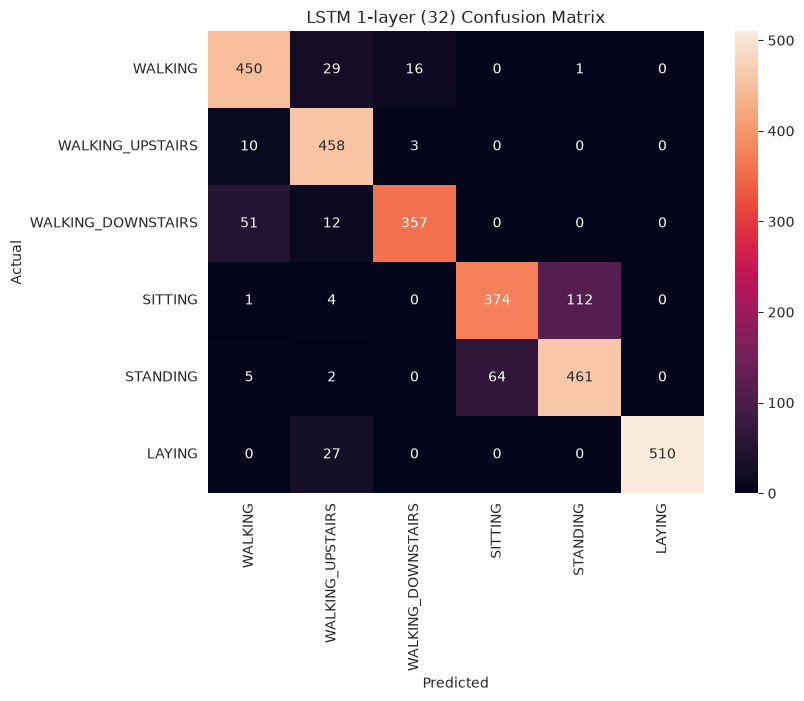

                    precision    recall  f1-score   support

           WALKING       0.87      0.91      0.89       496
  WALKING_UPSTAIRS       0.86      0.97      0.91       471
WALKING_DOWNSTAIRS       0.95      0.85      0.90       420
           SITTING       0.85      0.76      0.81       491
          STANDING       0.80      0.87      0.83       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.89      0.88      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



In [60]:
evaluate_lstm('LSTM 1-layer (32)', model)

### Model 2.1. 2-layer (48,32):

In [61]:
tf.keras.utils.set_random_seed(42)
model = Sequential([
    Input(shape=(timesteps, input_dim)),
    LSTM(48, return_sequences=True, bias_regularizer=reg),
    BatchNormalization(), Dropout(0.5),
    LSTM(32), Dropout(0.5),
    Dense(n_classes, activation='softmax')])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 128, 48)        │        11,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 48)        │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,894 (85.52 KB)

 Trainable params: 21,798 (85.15 KB)

 Non-trainable params: 96 (384.00 B)

In [62]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [63]:
model.fit(X_tr, Y_tr, batch_size=16, epochs=30, validation_data=(X_val, Y_val), verbose=0,
          callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

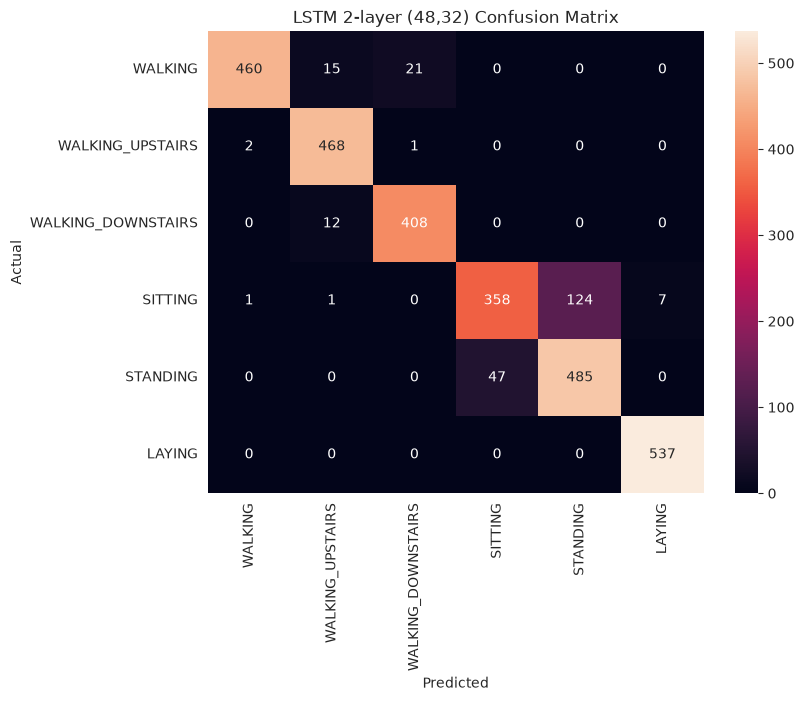

                    precision    recall  f1-score   support

           WALKING       0.99      0.93      0.96       496
  WALKING_UPSTAIRS       0.94      0.99      0.97       471
WALKING_DOWNSTAIRS       0.95      0.97      0.96       420
           SITTING       0.88      0.73      0.80       491
          STANDING       0.80      0.91      0.85       532
            LAYING       0.99      1.00      0.99       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



In [64]:
evaluate_lstm('LSTM 2-layer (48,32)', model)

### Model 2.2, 2-layer (64,48):

In [65]:
tf.keras.utils.set_random_seed(42)
model = Sequential([
    Input(shape=(timesteps, input_dim)),
    LSTM(64, return_sequences=True, bias_regularizer=reg),
    BatchNormalization(), Dropout(0.5),
    LSTM(48), Dropout(0.5),
    Dense(n_classes, activation='softmax')])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128, 64)        │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 48)             │        21,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,190 (160.90 KB)

 Trainable params: 41,062 (160.40 KB)

 Non-trainable params: 128 (512.00 B)

In [66]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [67]:
model.fit(X_tr, Y_tr, batch_size=16, epochs=30, validation_data=(X_val, Y_val), verbose=0,
          callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])

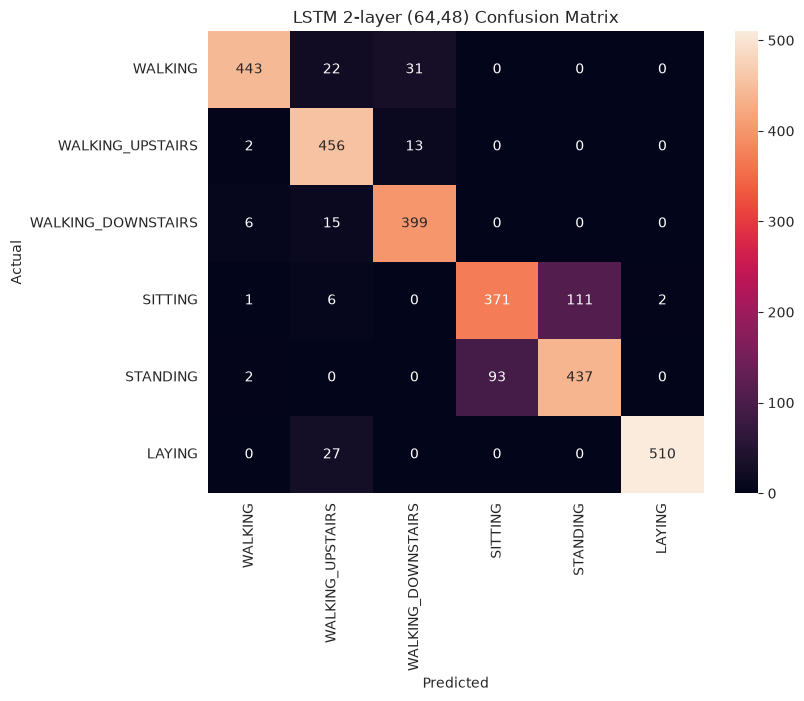

                    precision    recall  f1-score   support

           WALKING       0.98      0.89      0.93       496
  WALKING_UPSTAIRS       0.87      0.97      0.91       471
WALKING_DOWNSTAIRS       0.90      0.95      0.92       420
           SITTING       0.80      0.76      0.78       491
          STANDING       0.80      0.82      0.81       532
            LAYING       1.00      0.95      0.97       537

          accuracy                           0.89      2947
         macro avg       0.89      0.89      0.89      2947
      weighted avg       0.89      0.89      0.89      2947



In [68]:
evaluate_lstm('LSTM 2-layer (64,48)', model)

In [69]:
from prettytable import PrettyTable

table = PrettyTable()
table.title = "Model Comparison"
table.field_names = ['Model', 'Accuracy %', 'Precision %', 'Recall %', 'F1-score %', 'Loss']

for _, r in metrics_df.iterrows():
    table.add_row([r['Model'], round(r['Accuracy %'], 2), round(r['Precision %'], 2),
                   round(r['Recall %'], 2), round(r['F1-score %'], 2), '-'])
for name, acc, err, prec, rec, f1, loss in lstm_rows:
    table.add_row([name, round(acc, 2), round(prec, 2), round(rec, 2), round(f1, 2), round(loss, 3)])
print(table)

+---------------------------------------------------------------------------------+
|                                 Model Comparison                                |
+----------------------+------------+-------------+----------+------------+-------+
|        Model         | Accuracy % | Precision % | Recall % | F1-score % |  Loss |
+----------------------+------------+-------------+----------+------------+-------+
| Logistic Regression  |   96.54    |    96.71    |  96.48   |   96.54    |   -   |
|      Linear SVC      |   96.67    |    96.96    |  96.63   |    96.7    |   -   |
|  rbf SVM classifier  |   96.27    |    96.43    |  96.14   |   96.23    |   -   |
|     DecisionTree     |   86.22    |    86.25    |  85.86   |   85.93    |   -   |
|    Random Forest     |   91.45    |    91.74    |  91.02   |   91.18    |   -   |
|  LSTM 1-layer (32)   |   88.56    |    88.96    |  88.46   |   88.53    |  0.42 |
| LSTM 2-layer (48,32) |   92.16    |    92.56    |  92.22   |   92.17    | 

## Conclusion

### Classical Machine Learning

The classical machine learning models using the 561 engineered features achieved the strongest overall performance. Linear SVC achieved the highest accuracy of **96.67%**, followed by Logistic Regression at **96.54%** and RBF SVM at **96.27%**.

Random Forest achieved **91.45%**, while Decision Tree achieved **86.22%**.

### LSTM Models

The LSTM models were trained directly on the raw sensor signals using sequences of **128 time steps and 9 signal channels**, without using the 561 engineered features.

The best LSTM was the **2-layer LSTM (48, 32)**, which achieved **92.16% accuracy**, **92.17% F1-score**, and a test loss of **0.232**.

Although the best LSTM performed better than the Decision Tree, it remained below the best classical models. This suggests that the engineered features used by the classical models were highly effective for this dataset.

### Overall

Overall, the classical machine learning models performed better than the LSTM models on this dataset. **Linear SVC was the best-performing model with 96.67% accuracy**, while the best LSTM achieved 92.16%.

The results demonstrate that carefully engineered features can allow relatively simple machine learning models to achieve strong performance on human activity recognition tasks.

> **Note:** LSTM performance can vary slightly between training runs because neural network training involves random initialization and optimization. Therefore, small differences between LSTM runs should not be over-interpreted.